# Berka — data preparation

Cleans the raw Berka transaction file (`berka-dataset/trans.asc`), reorders within-day rows to minimize running-balance discrepancies, and re-labels Czech category strings into English. Outputs `trans-clean.asc` and `trans-clean-eng.asc` for downstream notebooks.


In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
datadir = os.path.join('berka-dataset')


In [3]:
# Load the data
raw_fn = os.path.join(datadir,"trans.asc")
raw = pd.read_csv(raw_fn,sep=";",header=0,dtype={"trans_id": "int",
                                                 "account_id": "string",
                                                 "date": "string",
                                                 "type": "category",
                                                 "operation": "category",
                                                 "amount": "float",
                                                 "balance": "float",
                                                 "k_symbol": "category",
                                                 "bank": "category",
                                                 "account": "string"})

In [4]:
# Fill in the empty categories
raw['type'] = raw['type'].cat.add_categories("None").fillna("None")
raw['operation'] = raw['operation'].cat.add_categories("None").fillna("None")
raw['k_symbol'] = raw['k_symbol'].cat.add_categories("None").fillna("None")
raw.loc[raw['k_symbol']==' ','k_symbol'] = "None"
raw.head()

,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account
0,695247,2378,930101,PRIJEM,VKLAD,700.0,700.0,None,NaN,<NA>
1,171812,576,930101,PRIJEM,VKLAD,900.0,900.0,None,NaN,<NA>
2,207264,704,930101,PRIJEM,VKLAD,1000.0,1000.0,None,NaN,<NA>
3,1117247,3818,930101,PRIJEM,VKLAD,600.0,600.0,None,NaN,<NA>
4,579373,1972,930102,PRIJEM,VKLAD,400.0,400.0,None,NaN,<NA>


#### Data cleaning


In [5]:
# Fix the cash withrdawal transactions where "VYBER" is copied into the wrong column
raw.loc[(raw["type"]=="VYBER") & (raw["operation"]=="VYBER"),"type"] = "VYDAJ"

### Order & balance inconsistencies

In [6]:
# Signed amount --> value
raw["value"] = raw["amount"]
raw.loc[raw["type"]=="VYDAJ","value"] = -1*raw.loc[raw["type"]=="VYDAJ","amount"]

In [7]:
# Let's count the balance discrepancies
discrepancies = []
for acct in raw["account_id"].unique():
    tmp = 0
    acct_bal = 0
    acct_history = raw[raw['account_id']==acct].copy()
    acct_idxs = acct_history.index
    acct_bals = []
    acct_errs = []
    # loop over the account history to track the running balance and flag the discrepancies
    for i, txn in acct_history.iterrows():
        # record the running balance
        acct_bal = acct_bal + txn["value"]
        acct_bals.append(acct_bal)
        # flag the transactions that result in balance discrepancies
        if round(tmp + txn["value"] - txn["balance"])!=0: acct_errs.append(i)
        # keep this reported balance to continue flagging subsequent discrepancies
        tmp = txn["balance"]
    # flag balance discrepancies
    acct_history["balance_running"] = acct_bals
    if acct_errs: 
        discrepancies.append(acct_history.loc[acct_errs])
# merge into one dataframe
discrepancies = pd.concat(discrepancies)

In [8]:
discrepancies.shape, raw.shape, discrepancies.shape[0]/raw.shape[0]

((331309, 12), (1056320, 11), 0.3136445395334747)

In [9]:
# Rearrange account histories (within days) to minimize discrepancies with the recorded balance
idx_map = {}
for acct in raw["account_id"].unique():
    acct_bal = 0
    acct_history = raw[raw['account_id']==acct]
    acct_idxs = []
    acct_tmp = []
    # If it just works, let it just work
    issue = False
    for i, txn in acct_history.iterrows():
        tmp = acct_bal + txn["value"]
        if not issue and round(tmp-txn["balance"])==0:
            acct_idxs.append(i)
            acct_bal = tmp
        else:
            issue = True
            acct_tmp.append((i,txn))
    # otherwise, pick the transaction with the smallest deviation that day and reset to the given balance
    while acct_tmp:
        # Great -- we can identify these. Now let's see if there is a consistent sorting that we can undo. Or swaps. NOPE.
        #date_tmp =  acct_tmp[0][1]["date"]
        #for i, txn in acct_tmp:
        #    if txn["date"]==date_tmp:
        #        print(date_tmp, txn["type"], txn["operation"], txn["k_symbol"], abs((acct_bal + txn["value"])-txn["balance"]))
        # 
        discrepancy = [abs((acct_bal + txn["value"])-txn["balance"]) if txn["date"]==acct_tmp[0][1]["date"] else np.inf for i, txn in acct_tmp]
        min_idx = min(range(len(discrepancy)), key=discrepancy.__getitem__)
        #print("")#print(min_idx,discrepancy[min_idx])
        i, txn = acct_tmp.pop(min_idx)
        acct_idxs.append(i)
        acct_bal = txn["balance"]
        # and try the whole list in case this resolved the entire issue :)
        acct_tmp_tmp = []
        issue = False
        for i, txn in acct_tmp:
            tmp = acct_bal + txn["value"]
            if not issue and round(tmp-txn["balance"])==0:
                acct_idxs.append(i)
                acct_bal = tmp
            else:
                issue = True
                acct_tmp_tmp.append((i,txn))
        acct_tmp = acct_tmp_tmp
    # Now use the column of indices to rearrange these particular indices of the dataframe
    old_idx = list(raw.loc[raw['account_id']==acct].index)
    if len(old_idx)==len(acct_idxs):
        for old, new in zip(old_idx,acct_idxs):
            idx_map[old] = new
    else:
        # Revolt if they're not the same length
        raise(ValueError("You're not capturing all the transactions. This is bad."))
# Get the new index
new_idx = [idx_map[old] for old in list(raw.index)]
# Reindex the dataframe
txns = raw.reindex(new_idx)

In [10]:
# Note remaining balance discrepancies
discrepancies = []
for acct in txns["account_id"].unique():
    tmp = 0
    acct_bal = 0
    acct_history = txns[txns['account_id']==acct].copy()
    acct_idxs = acct_history.index
    acct_bals = []
    acct_errs = []
    # loop over the account history to track the running balance and flag the discrepancies
    for i, txn in acct_history.iterrows():
        # record the running balance
        acct_bal = acct_bal + txn["value"]
        acct_bals.append(acct_bal)
        # flag the transactions that result in balance discrepancies
        if round(tmp + txn["value"] - txn["balance"])!=0: acct_errs.append(i)
        # keep this reported balance to continue flagging subsequent discrepancies
        tmp = txn["balance"]
    # flag balance discrepancies
    acct_history["balance_running"] = acct_bals
    if acct_errs: 
        discrepancies.append(acct_history.loc[acct_errs])
# merge into one dataframe
discrepancies = pd.concat(discrepancies)
discrepancies

,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account,value,balance_running
773252,3462664,2566,980131,PRIJEM,None,0.4,4000.4,UROK,NaN,<NA>,0.4,3200.4
801291,752229,2566,980302,PRIJEM,VKLAD,1100.0,4300.4,None,NaN,<NA>,1100.0,4300.4
799530,3488456,7445,980228,PRIJEM,None,0.2,9072.8,UROK,NaN,<NA>,0.2,9059.4
815395,2256591,7445,980322,VYDAJ,VYBER,100.0,8958.2,None,NaN,<NA>,-100.0,8959.4
27896,3670845,5442,931231,VYDAJ,VYBER,0.2,22314.0,SANKC. UROK,NaN,<NA>,-0.2,22299.5
...,...,...,...,...,...,...,...,...,...,...,...,...
1043319,390993,1330,981212,VYDAJ,VYBER,9500.0,-9373.4,SIPO,NaN,0,-9500.0,-9373.0
585344,3444659,5878,970630,VYDAJ,VYBER,0.3,-21.6,SANKC. UROK,NaN,<NA>,-0.3,-36.0
593665,1733162,5878,970709,PRIJEM,VKLAD,10807.0,10770.8,None,NaN,<NA>,10807.0,10771.0
955230,3531688,37,980831,VYDAJ,VYBER,0.4,15541.7,SANKC. UROK,NaN,<NA>,-0.4,15527.2


The dataset is very precise. Nice.

In [11]:
# Save the updated data
txns_fn = os.path.join(datadir,"trans-clean.asc")
txns.to_csv(txns_fn,sep=";",index=False)

#### Now let's make it self-explanatory in English

In [12]:
# Create more interpretable labels (in English)
eng = txns.copy()
eng["categ"] = "test"
eng["detail"] = "test"

# relabeling dictionaries
detail = {}
detail[('PRIJEM','VKLAD','None')] = 'N/A'
detail[('PRIJEM','None','UROK')] = 'Interest'
detail[('PRIJEM','PREVOD Z UCTU','None')] = 'N/A'
detail[('PRIJEM','PREVOD Z UCTU','DUCHOD')] = "Pension"
detail[('VYDAJ','VYBER','None')] = 'N/A'
detail[('VYDAJ','VYBER','SLUZBY')] = 'Service'
detail[('VYDAJ','VYBER','SIPO')] = "Household"
detail[('VYDAJ','VYBER','SANKC. UROK')] = "Interest"
detail[('VYDAJ','VYBER','POJISTNE')] = "Insurance"
detail[('VYDAJ','VYBER KARTOU','None')] = 'N/A'
detail[('VYDAJ','PREVOD NA UCET','None')] = 'N/A'
detail[('VYDAJ','PREVOD NA UCET','POJISTNE')] = "Insurance"
detail[('VYDAJ','PREVOD NA UCET','SIPO')] = "Household"
detail[('VYDAJ','PREVOD NA UCET','UVER')] = "Loan"
categ = {}
categ[('PRIJEM','VKLAD','None')] = "Deposit"
categ[('PRIJEM','None','UROK')] = "Fee"
categ[('PRIJEM','PREVOD Z UCTU','None')] = "Transfer"
categ[('PRIJEM','PREVOD Z UCTU','DUCHOD')] = "Transfer"
categ[('VYDAJ','VYBER','None')] = "Withdrawal"
categ[('VYDAJ','VYBER','SLUZBY')] = "Fee"
categ[('VYDAJ','VYBER','SIPO')] = "Withdrawal"
categ[('VYDAJ','VYBER','SANKC. UROK')] = "Fee"
categ[('VYDAJ','VYBER','POJISTNE')] = "Withdrawal"
categ[('VYDAJ','VYBER KARTOU','None')] = "Card Payment"
categ[('VYDAJ','PREVOD NA UCET','None')] = "Transfer"
categ[('VYDAJ','PREVOD NA UCET','POJISTNE')] = "Transfer"
categ[('VYDAJ','PREVOD NA UCET','SIPO')] = "Transfer"
categ[('VYDAJ','PREVOD NA UCET','UVER')] = "Transfer"
# relabel
for terms, label in categ.items():
    indices = eng[(eng["type"]==terms[0]) & (eng["operation"]==terms[1]) & (eng["k_symbol"]==terms[2])].index
    eng.loc[indices,'categ'] = label
for terms, label in detail.items():
    indices = eng[(eng["type"]==terms[0]) & (eng["operation"]==terms[1]) & (eng["k_symbol"]==terms[2])].index
    eng.loc[indices,'detail'] = label
    
# type column
eng["type"] =  eng["type"].cat.rename_categories({'PRIJEM':'CREDIT', 'VYDAJ':'DEBIT'}).cat.remove_unused_categories()

# remove czech columns
eng = eng.drop(['operation','k_symbol'], axis=1)

In [13]:
totals = eng.agg({"trans_id":'count',"date":pd.Series.nunique,"account_id":pd.Series.nunique,"amount":['sum','mean']})

In [14]:
# Let's make a table of the most intuitive categories of transaction types
types = eng.groupby(["categ"]).agg({"trans_id":'count',"date":pd.Series.nunique,"account_id":pd.Series.nunique,"amount":['sum','mean']})
types = types.loc[types["trans_id"]["count"]!=0]
types["trans_id","perc"] = types["trans_id"]["count"]/totals['trans_id']['count']*100
types["amount","perc"] = types["amount"]["sum"]/totals['amount']['sum']*100
types = types.sort_index(axis=1)
types

account_id        amount                             date  \
                nunique          mean       perc           sum nunique   
categ                                                                    
Card Payment        807   2261.124938   0.290364  1.817040e+07    1228   
Deposit            4500  15429.855126  38.648155  2.418522e+09    2190   
Fee                4453     88.671752   0.482515  3.019477e+07      72   
Transfer           3712   5316.526108  23.236908  1.454118e+09     717   
Withdrawal         4500   8420.587685  37.342057  2.336789e+09    2142   

             trans_id             
                count       perc  
categ                             
Card Payment     8036   0.760754  
Deposit        156743  14.838591  
Fee            340523  32.236728  
Transfer       273509  25.892627  
Withdrawal     277509  26.271300

In [15]:
# Save the updated data
eng_fn = os.path.join(datadir,"trans-clean-eng.asc")
eng.to_csv(eng_fn,sep=";",index=False)

#### Running balance

In [16]:
# Compute the running balance
txns["balance_run"] = None
# loop over the account history
for acct in txns["account_id"].unique():
    tmp = 0
    acct_bal = 0
    acct_history = txns[txns['account_id']==acct]
    acct_idxs = acct_history.index
    acct_bals = []
    acct_errs = []
    for i, txn in acct_history.iterrows():
        # record the running balance
        acct_bal = acct_bal + txn["value"]
        acct_bals.append(acct_bal)
    # record the running balance and the discrepancies
    txns.loc[acct_idxs,"balance_run"] = acct_bals

In [17]:
# Very small number of errors, and the errors are very small
print("d >= 0    ", sum((txns["balance"]-txns["balance_run"]).abs()>=0))
print("d >  0    ", sum((txns["balance"]-txns["balance_run"]).abs()>0))
print("d >  1    ", sum((txns["balance"]-txns["balance_run"]).abs()>1))
print("d >  10   ", sum((txns["balance"]-txns["balance_run"]).abs()>10))
print("d >  100  ", sum((txns["balance"]-txns["balance_run"]).abs()>100))
print("d >  1000 ", sum((txns["balance"]-txns["balance_run"]).abs()>1000))

d >= 0     1056320
d >  0     981916
d >  1     8684
d >  10    48
d >  100   5
d >  1000  2


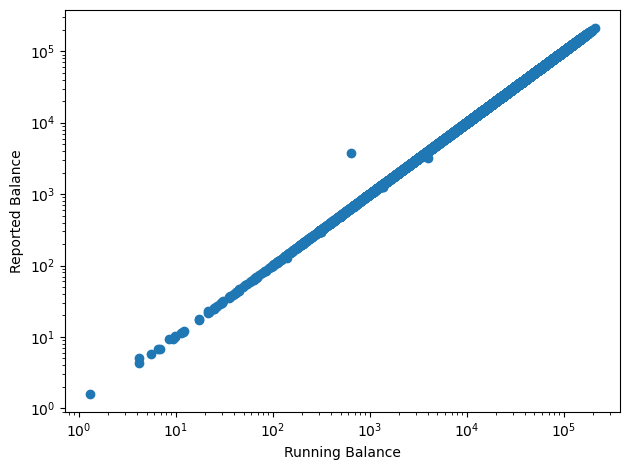

In [18]:
## Plot -- reported vs. running balance
import matplotlib.pyplot as plt

# get the two values
x_bal = txns["balance"]
y_bal = txns["balance_run"]

plot = plt.loglog(x_bal,y_bal,color="#1f77b4",marker="o",linestyle="")

# labels
plt.xlabel("Running Balance")
plt.ylabel("Reported Balance");
# save
plt.tight_layout()
plt.show()

In [19]:
# Suppose we can also compute the correlation
txns[["balance","balance_run"]].corr()

,balance,balance_run
balance,1.0,1.0
balance_run,1.0,1.0


Hahaha!